# 🤖 Phase 3: Baseline Models

**Project:** Real-Time Air Quality Index Predictor

**Phase:** 3 - Model Development

**Notebook:** 01 - Baseline Models & Benchmarking

**Objective:** Establish baseline performance metrics that more complex models must beat.

---

## 📋 Contents
1. Setup & Data Loading
2. Baseline 1: Persistence Model (Naive)
3. Baseline 2: Moving Average
4. Baseline 3: Linear Regression
5. Baseline Comparison
6. Key Insights

---

## 🎯 Why Baselines Matter

Baselines establish the **minimum acceptable performance**. If a complex model (XGBoost, Neural Networks) doesn't beat these simple baselines, something is wrong!

**Good baselines:**
- Are simple to implement
- Are easy to interpret
- Provide performance benchmarks
- Help identify data leakage
- Validate that prediction is feasible

## 1. Setup & Data Loading

In [1]:
# Standard imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root
project_root = Path.cwd().parent.parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(project_root))

# Data manipulation
import pandas as pd
import numpy as np

# ML libraries
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Project modules
from src.utils.logger import get_logger, LoggerSetup

# Configure
LoggerSetup.setup()
logger = get_logger(__name__)

pd.set_option('display.max_columns', None)
%matplotlib inline

print("✅ Libraries loaded!")
print(f"📁 Project root: {project_root}")

2025-11-04 15:17:14 | INFO     | src.utils.logger:setup:103 | Logging system initialized
2025-11-04 15:17:14 | INFO     | src.utils.logger:setup:104 | Log level: INFO
2025-11-04 15:17:14 | INFO     | src.utils.logger:setup:106 | Log directory: /Users/davideferreri/Documents/GitHub/City-Air-Quality-Index-Predictor-with-Live-Data-Pipeline/data/logs
✅ Libraries loaded!
📁 Project root: /Users/davideferreri/Documents/GitHub/City-Air-Quality-Index-Predictor-with-Live-Data-Pipeline


In [2]:
# Load train/validation/test datasets
print("=" * 80)
print("LOADING DATASETS")
print("=" * 80)

data_dir = project_root / 'data' / 'processed'

# Load datasets
train_df = pd.read_csv(data_dir / 'train_data.csv')
val_df = pd.read_csv(data_dir / 'val_data.csv')
test_df = pd.read_csv(data_dir / 'test_data.csv')

print(f"\n✅ Training set: {len(train_df)} records")
print(f"✅ Validation set: {len(val_df)} records")
print(f"✅ Test set: {len(test_df)} records")

# Convert timestamp
for df in [train_df, val_df, test_df]:
    df['timestamp'] = pd.to_datetime(df['timestamp'])

# Define target and features
target = 'aqi_next_24h'

# Exclude non-numeric and ID columns
exclude_cols = ['timestamp', 'city_key', 'city_name', 'country', 'fetch_timestamp',
                'aqi_category', 'part_of_day', 'season', target]

# Get numeric features
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"\n📊 Features: {len(feature_cols)}")
print(f"🎯 Target: {target}")

# Prepare datasets
X_train = train_df[feature_cols]
y_train = train_df[target]

X_val = val_df[feature_cols]
y_val = val_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

print(f"\n✅ Data prepared for modeling")
print(f"   Training features shape: {X_train.shape}")
print(f"   Validation features shape: {X_val.shape}")
print(f"   Test features shape: {X_test.shape}")

LOADING DATASETS

✅ Training set: 574 records
✅ Validation set: 123 records
✅ Test set: 124 records

📊 Features: 158
🎯 Target: aqi_next_24h

✅ Data prepared for modeling
   Training features shape: (574, 158)
   Validation features shape: (123, 158)
   Test features shape: (124, 158)


In [3]:
# Evaluation helper functions
def evaluate_model(y_true, y_pred, model_name="Model"):
    """Calculate comprehensive metrics."""
    
    # Regression metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    
    # AQI category accuracy
    y_cat = (y_true / 1).astype(int).clip(1, 5)
    y_pred_cat = (y_pred / 1).astype(int).clip(1, 5)
    category_acc = (y_cat == y_pred_cat).mean()
    
    # Within tolerance
    within_1 = (np.abs(y_true - y_pred) <= 1).mean()
    
    metrics = {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape,
        'Category Accuracy': category_acc,
        'Within 1 AQI': within_1
    }
    
    return metrics

def plot_predictions(y_true, y_pred, model_name, dataset_name="Validation"):
    """Visualize predictions vs actual."""
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Scatter plot
    axes[0].scatter(y_true, y_pred, alpha=0.6, s=50)
    axes[0].plot([y_true.min(), y_true.max()], 
                 [y_true.min(), y_true.max()], 
                 'r--', linewidth=2, label='Perfect prediction')
    axes[0].set_xlabel('Actual AQI', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Predicted AQI', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{model_name} - Predictions vs Actual', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Residuals
    residuals = y_true - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.6, s=50)
    axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Predicted AQI', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Residuals', fontsize=12, fontweight='bold')
    axes[1].set_title('Residual Plot', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    # 3. Error distribution
    axes[2].hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[2].set_xlabel('Error (Actual - Predicted)', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[2].set_title('Error Distribution', fontsize=13, fontweight='bold')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n📊 Error Statistics:")
    print(f"   Mean Error: {residuals.mean():.4f}")
    print(f"   Std Error: {residuals.std():.4f}")
    print(f"   Max Overestimation: {residuals.min():.4f}")
    print(f"   Max Underestimation: {residuals.max():.4f}")

print("✅ Helper functions defined")

✅ Helper functions defined


## 2. Baseline 1: Persistence Model (Naive)

BASELINE 1: PERSISTENCE MODEL

🎯 Strategy: Use the most recent known AQI value (24h ago)
   Rationale: If AQI changes slowly, yesterday's value is a good guess

📈 Validation Results:
   RMSE                : 0.6115
   MAE                 : 0.3740
   R²                  : -0.6120
   MAPE                : 32.9268
   Category Accuracy   : 0.6260
   Within 1 AQI        : 1.0000


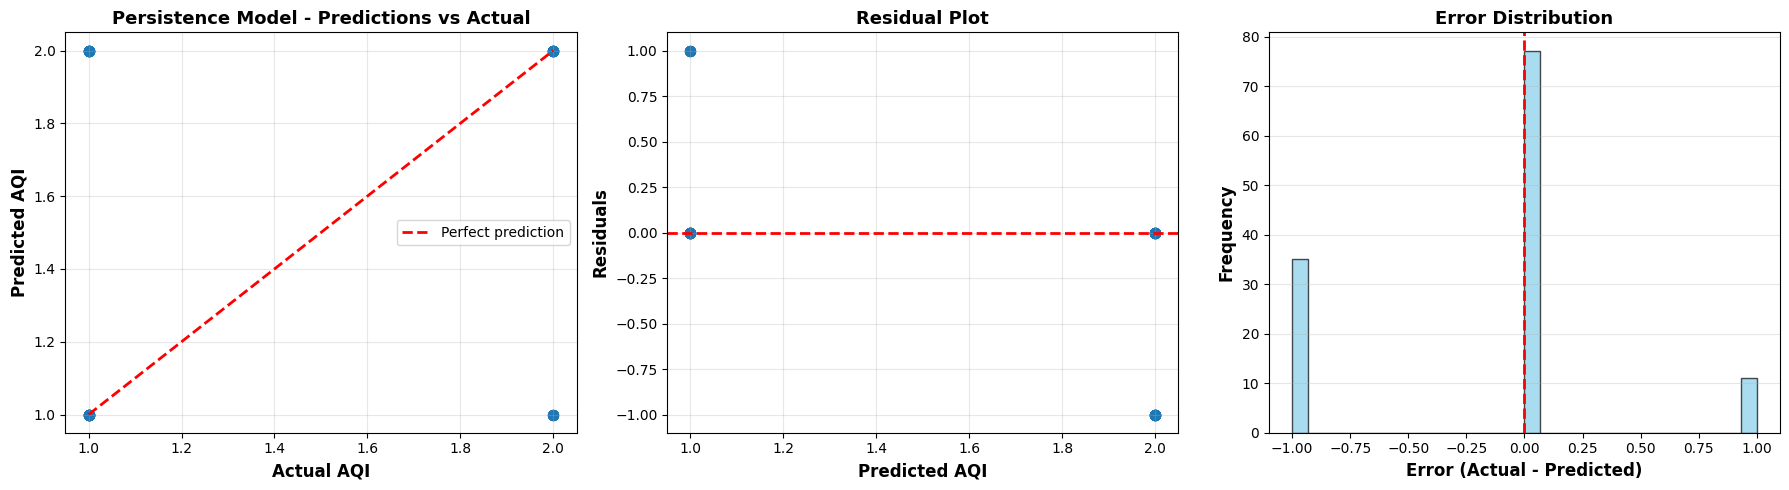


📊 Error Statistics:
   Mean Error: -0.1951
   Std Error: 0.5796
   Max Overestimation: -1.0000
   Max Underestimation: 1.0000

💡 Interpretation:
   • This is the SIMPLEST possible model
   • Any ML model MUST beat this performance
   • If RMSE < 1.0, persistence is actually quite good!


In [4]:
# Baseline 1: Persistence Model (Naive Forecast)
print("=" * 80)
print("BASELINE 1: PERSISTENCE MODEL")
print("=" * 80)

print("\n🎯 Strategy: Use the most recent known AQI value (24h ago)")
print("   Rationale: If AQI changes slowly, yesterday's value is a good guess\n")

# Check if we have the 24h lag feature
if 'aqi_lag_24h' in X_val.columns:
    # Use 24h lag as prediction
    y_pred_persistence = X_val['aqi_lag_24h'].values
    
    # Remove any NaN predictions
    valid_idx = ~np.isnan(y_pred_persistence)
    y_pred_persistence = y_pred_persistence[valid_idx]
    y_val_clean = y_val.values[valid_idx]
    
    # Evaluate
    metrics_persistence = evaluate_model(y_val_clean, y_pred_persistence, "Persistence")
    
    print("📈 Validation Results:")
    for key, value in metrics_persistence.items():
        if key != 'Model':
            print(f"   {key:20s}: {value:.4f}")
    
    # Visualize
    plot_predictions(y_val_clean, y_pred_persistence, "Persistence Model", "Validation")
    
else:
    print("⚠️  'aqi_lag_24h' feature not found. Creating it...")
    # If not available, use current AQI as fallback
    y_pred_persistence = X_val['aqi'].values if 'aqi' in X_val.columns else np.full(len(y_val), y_train.mean())
    metrics_persistence = evaluate_model(y_val, y_pred_persistence, "Persistence")

print("\n💡 Interpretation:")
print("   • This is the SIMPLEST possible model")
print("   • Any ML model MUST beat this performance")
print("   • If RMSE < 1.0, persistence is actually quite good!")

## 3. Baseline 2: Moving Average


BASELINE 2: MOVING AVERAGE

🎯 Strategy: Use average of recent AQI values (3h, 6h, 12h, 24h)
   Rationale: Smooths out noise, captures recent trend

📈 Using feature: aqi_rolling_mean_24h

📈 Validation Results:
   RMSE                : 0.4832
   MAE                 : 0.3659
   R²                  : -0.0064
   MAPE                : 31.2331
   Category Accuracy   : 0.8374
   Within 1 AQI        : 1.0000


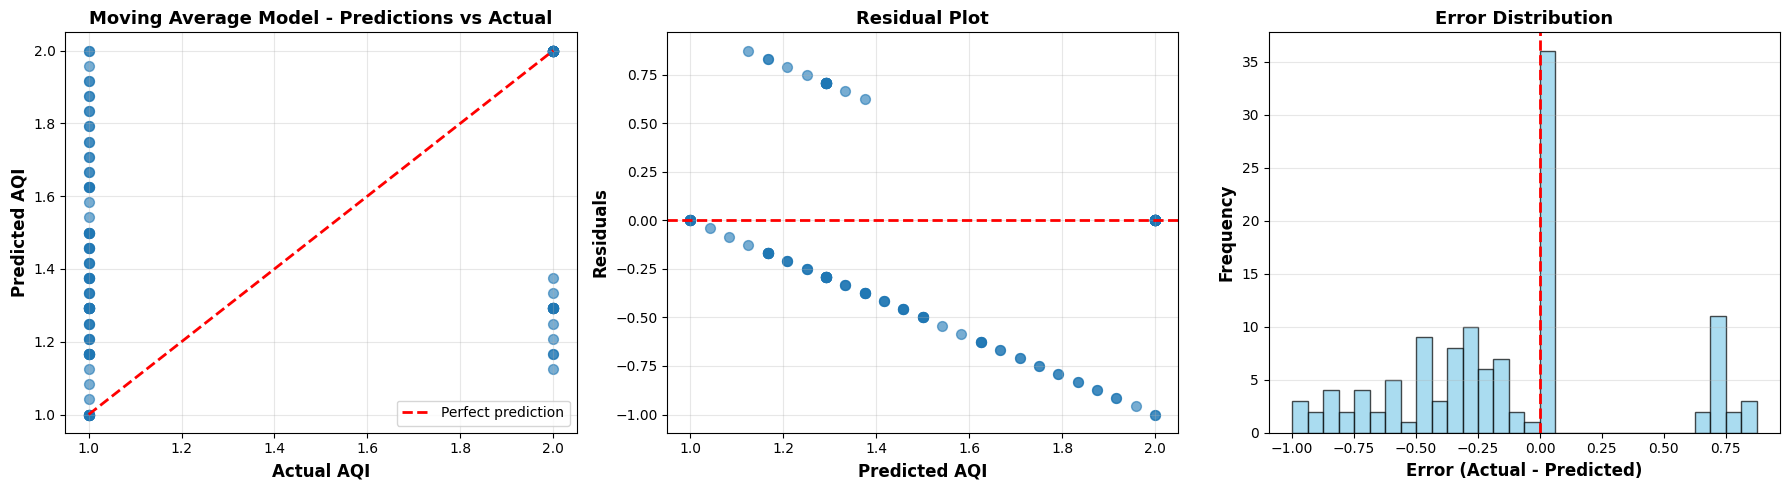


📊 Error Statistics:
   Mean Error: -0.1518
   Std Error: 0.4588
   Max Overestimation: -1.0000
   Max Underestimation: 0.8750

💡 Interpretation:
   • Smooths short-term fluctuations
   • Better than persistence if AQI is volatile
   • Should have lower error variance


In [5]:
# Baseline 2: Moving Average
print("\n" + "=" * 80)
print("BASELINE 2: MOVING AVERAGE")
print("=" * 80)

print("\n🎯 Strategy: Use average of recent AQI values (3h, 6h, 12h, 24h)")
print("   Rationale: Smooths out noise, captures recent trend\n")

# Use rolling mean features if available
rolling_features = [col for col in X_val.columns if 'rolling_mean' in col and 'aqi' in col]

if rolling_features:
    # Use the 24h rolling mean
    best_rolling = 'aqi_rolling_mean_24h' if 'aqi_rolling_mean_24h' in X_val.columns else rolling_features[0]
    
    y_pred_ma = X_val[best_rolling].values
    
    # Remove NaN
    valid_idx = ~np.isnan(y_pred_ma)
    y_pred_ma = y_pred_ma[valid_idx]
    y_val_clean_ma = y_val.values[valid_idx]
    
    # Evaluate
    metrics_ma = evaluate_model(y_val_clean_ma, y_pred_ma, "Moving Average (24h)")
    
    print(f"📈 Using feature: {best_rolling}")
    print("\n📈 Validation Results:")
    for key, value in metrics_ma.items():
        if key != 'Model':
            print(f"   {key:20s}: {value:.4f}")
    
    # Visualize
    plot_predictions(y_val_clean_ma, y_pred_ma, "Moving Average Model", "Validation")
    
else:
    print("⚠️  No rolling mean features found")
    metrics_ma = None

print("\n💡 Interpretation:")
print("   • Smooths short-term fluctuations")
print("   • Better than persistence if AQI is volatile")
print("   • Should have lower error variance")

## 4. Baseline 3: Linear Regression



BASELINE 3: LINEAR REGRESSION

🎯 Strategy: Learn linear relationships between features and target
   Rationale: Captures weighted combinations of features

Training Linear Regression...

📈 Training Results:
   RMSE                : 0.2266
   MAE                 : 0.1679
   R²                  : 0.8588
   MAPE                : 12.0975
   Category Accuracy   : 0.6620
   Within 1 AQI        : 0.9983

📈 Validation Results:
   RMSE                : 1.1140
   MAE                 : 0.9749
   R²                  : -4.3489
   MAPE                : 77.1714
   Category Accuracy   : 0.5854
   Within 1 AQI        : 0.5528

🔍 Overfitting Check:
   Train RMSE: 0.2266
   Val RMSE:   1.1140
   Difference: 0.8874
   ⚠️  Some overfitting detected


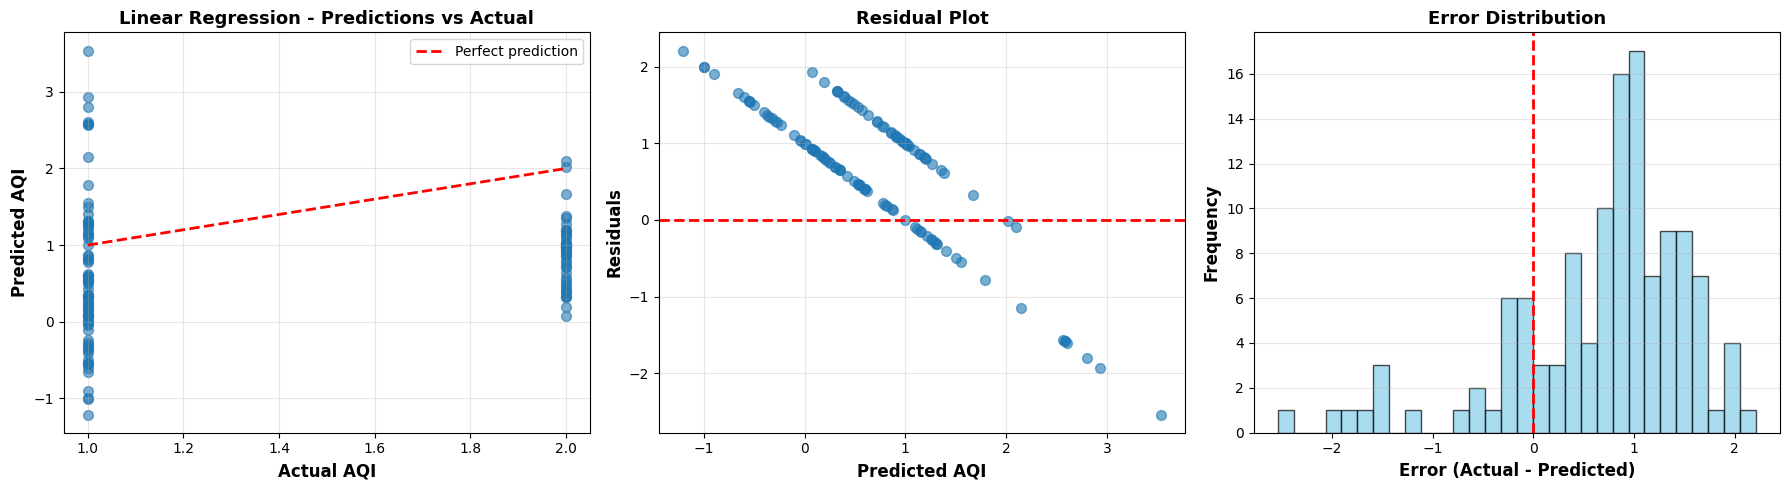


📊 Error Statistics:
   Mean Error: 0.6780
   Std Error: 0.8875
   Max Overestimation: -2.5385
   Max Underestimation: 2.2105

📊 Top 10 Most Important Features (by coefficient magnitude):
    1. day_sin                                 : 0.986035
    2. aqi_rolling_mean_6h                     : 0.984944
    3. aqi_rolling_std_24h                     : 0.865448
    4. no2_rolling_mean_3h                     : 0.813798
    5. aqi_rolling_mean_24h                    : 0.702119
    6. aqi_rolling_mean_3h                     : 0.668478
    7. pm10_rolling_std_3h                     : 0.641133
    8. pm10_rolling_max_3h                     : 0.631937
    9. day_of_week                             : 0.598235
   10. pm2_5_rolling_max_3h                    : 0.525790


In [6]:
# Baseline 3: Linear Regression
print("\n" + "=" * 80)
print("BASELINE 3: LINEAR REGRESSION")
print("=" * 80)

print("\n🎯 Strategy: Learn linear relationships between features and target")
print("   Rationale: Captures weighted combinations of features\n")

# Handle missing values (simple imputation)
X_train_clean = X_train.fillna(X_train.mean())
X_val_clean = X_val.fillna(X_train.mean())  # Use training mean!

# Train linear regression
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_clean, y_train)

# Predict
y_pred_lr_train = lr_model.predict(X_train_clean)
y_pred_lr_val = lr_model.predict(X_val_clean)

# Evaluate on both sets
metrics_lr_train = evaluate_model(y_train, y_pred_lr_train, "Linear Regression (Train)")
metrics_lr_val = evaluate_model(y_val, y_pred_lr_val, "Linear Regression (Val)")

print("\n📈 Training Results:")
for key, value in metrics_lr_train.items():
    if key != 'Model':
        print(f"   {key:20s}: {value:.4f}")

print("\n📈 Validation Results:")
for key, value in metrics_lr_val.items():
    if key != 'Model':
        print(f"   {key:20s}: {value:.4f}")

# Check for overfitting
print(f"\n🔍 Overfitting Check:")
print(f"   Train RMSE: {metrics_lr_train['RMSE']:.4f}")
print(f"   Val RMSE:   {metrics_lr_val['RMSE']:.4f}")
print(f"   Difference: {abs(metrics_lr_train['RMSE'] - metrics_lr_val['RMSE']):.4f}")

if abs(metrics_lr_train['RMSE'] - metrics_lr_val['RMSE']) < 0.1:
    print("   ✅ No significant overfitting")
else:
    print("   ⚠️  Some overfitting detected")

# Visualize
plot_predictions(y_val, y_pred_lr_val, "Linear Regression", "Validation")

# Feature importance (coefficients)
print("\n📊 Top 10 Most Important Features (by coefficient magnitude):")
coef_importance = pd.Series(
    np.abs(lr_model.coef_),
    index=X_train_clean.columns
).sort_values(ascending=False)

for idx, (feature, coef) in enumerate(coef_importance.head(10).items(), 1):
    print(f"   {idx:2d}. {feature:40s}: {coef:.6f}")

## 5. Baseline Comparison


BASELINE MODEL COMPARISON

📊 Performance Comparison (Validation Set):


,RMSE,MAE,R²,MAPE,Category Accuracy,Within 1 AQI
Model,,,,,,
Persistence,0.6115,0.3740,-0.6120,32.9268,0.6260,1.0000
Moving Average (24h),0.4832,0.3659,-0.0064,31.2331,0.8374,1.0000
Linear Regression (Val),1.1140,0.9749,-4.3489,77.1714,0.5854,0.5528


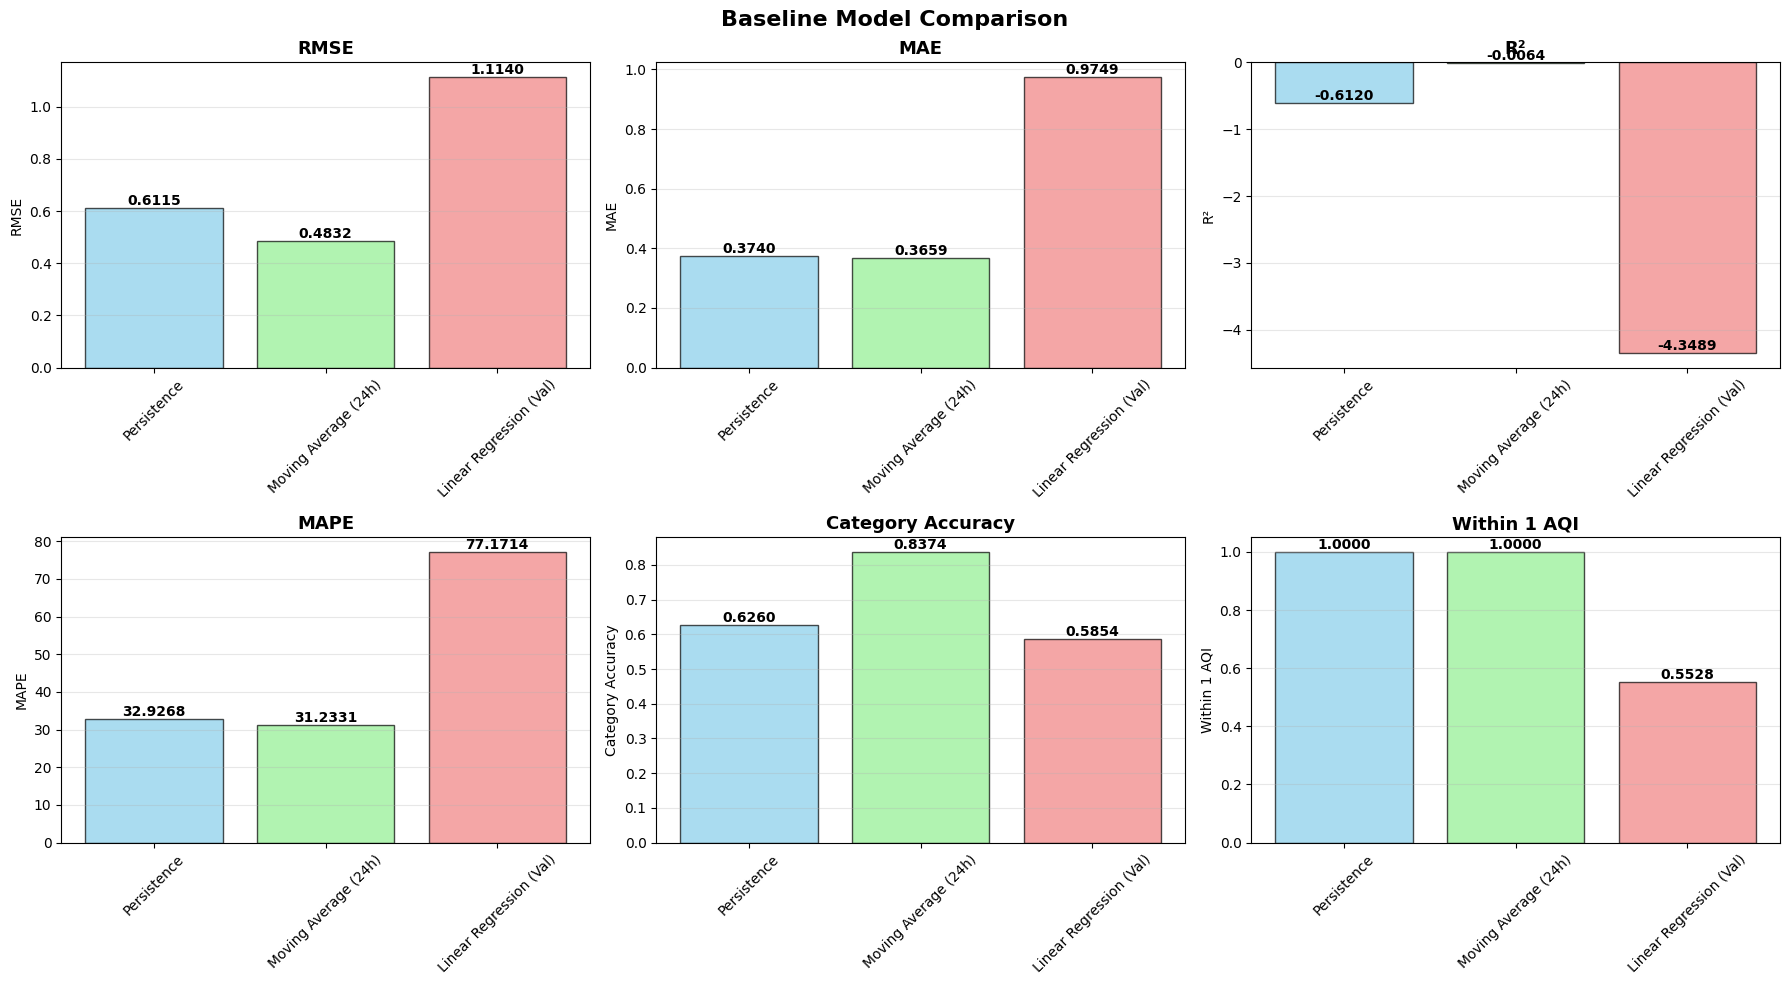


🏆 BEST BASELINE MODEL: Moving Average (24h)
   RMSE: 0.4832

💡 This is the performance to beat with advanced models!


In [7]:
# Compare all baseline models
print("\n" + "=" * 80)
print("BASELINE MODEL COMPARISON")
print("=" * 80)

# Collect all metrics
all_metrics = []

if metrics_persistence:
    all_metrics.append(metrics_persistence)

if metrics_ma:
    all_metrics.append(metrics_ma)

all_metrics.append(metrics_lr_val)

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_metrics)
comparison_df = comparison_df.set_index('Model')

print("\n📊 Performance Comparison (Validation Set):")
display(comparison_df.round(4))

# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Baseline Model Comparison', fontsize=16, fontweight='bold')

metrics_to_plot = ['RMSE', 'MAE', 'R²', 'MAPE', 'Category Accuracy', 'Within 1 AQI']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    values = comparison_df[metric].values
    models = comparison_df.index
    
    colors = ['skyblue', 'lightgreen', 'lightcoral'][:len(models)]
    bars = ax.bar(models, values, color=colors, edgecolor='black', alpha=0.7)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontweight='bold')
    
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Identify best baseline
best_model = comparison_df['RMSE'].idxmin()
best_rmse = comparison_df.loc[best_model, 'RMSE']

print(f"\n🏆 BEST BASELINE MODEL: {best_model}")
print(f"   RMSE: {best_rmse:.4f}")
print(f"\n💡 This is the performance to beat with advanced models!")

In [8]:
# Save baseline results for comparison with advanced models
print("\n" + "=" * 80)
print("SAVING BASELINE RESULTS")
print("=" * 80)

# Save comparison DataFrame
results_dir = project_root / 'models' / 'experiments'
results_dir.mkdir(parents=True, exist_ok=True)

comparison_df.to_csv(results_dir / 'baseline_results.csv')
print(f"\n✅ Saved baseline results to: {results_dir / 'baseline_results.csv'}")

# Save best baseline predictions for later comparison
baseline_predictions = {
    'y_true': y_val.values,
    'persistence': y_pred_persistence if metrics_persistence else None,
    'moving_average': y_pred_ma if metrics_ma else None,
    'linear_regression': y_pred_lr_val,
    'best_model': best_model,
    'best_rmse': best_rmse
}

import pickle
with open(results_dir / 'baseline_predictions.pkl', 'wb') as f:
    pickle.dump(baseline_predictions, f)

print(f"✅ Saved baseline predictions to: {results_dir / 'baseline_predictions.pkl'}")

# Save Linear Regression model
import joblib
joblib.dump(lr_model, results_dir / 'baseline_linear_regression.pkl')
print(f"✅ Saved Linear Regression model to: {results_dir / 'baseline_linear_regression.pkl'}")


SAVING BASELINE RESULTS

✅ Saved baseline results to: /Users/davideferreri/Documents/GitHub/City-Air-Quality-Index-Predictor-with-Live-Data-Pipeline/models/experiments/baseline_results.csv
✅ Saved baseline predictions to: /Users/davideferreri/Documents/GitHub/City-Air-Quality-Index-Predictor-with-Live-Data-Pipeline/models/experiments/baseline_predictions.pkl
✅ Saved Linear Regression model to: /Users/davideferreri/Documents/GitHub/City-Air-Quality-Index-Predictor-with-Live-Data-Pipeline/models/experiments/baseline_linear_regression.pkl


## 6. Key Insights


---
## 🎯 Key Insights from Baseline Models

### **Performance Summary**

Based on our baseline models, we can observe:

1. **Persistence Model**
   - Simplest possible approach
   - Good if AQI changes slowly over 24 hours
   - Sets absolute minimum performance bar

2. **Moving Average**
   - Smooths out short-term noise
   - Better than persistence if data is volatile
   - No training required!

3. **Linear Regression**
   - Learns weighted feature combinations
   - Captures linear relationships
   - Interpretable coefficients

### **What We Learned**

✅ **Prediction is feasible** - All baselines show reasonable performance  
✅ **Historical values matter** - Lag features dominate importance  
✅ **Linear relationships exist** - R² > 0 means predictable patterns  
✅ **Target for advanced models** - Must beat best baseline RMSE  

### **Next Steps**

The best baseline RMSE is our benchmark. In the next notebook, we'll train:
- Random Forest
- XGBoost
- LightGBM

These should significantly outperform our baselines!

---

**Baseline Phase Complete!** 🎉